In [44]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
TICKERS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "META",
    "NVDA",
    "JPM",
    "XOM",
    "JNJ",
    "KO"
]

prices = yf.download(
    TICKERS,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  9 of 10 completed


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,XOM
Date,,,,,,,,,,
2015-01-02,24.171755,15.4260,26.227924,75.737358,45.838100,29.215921,77.705742,39.607182,0.481884,56.777905
2015-01-05,23.490801,15.1095,25.728178,75.208397,44.415054,29.215921,76.457718,39.242950,0.473745,55.224373
2015-01-06,23.493015,14.7645,25.093220,74.838860,43.263420,29.437790,75.427567,38.666969,0.459382,54.930779
2015-01-07,23.822435,14.9210,25.019426,76.491020,43.329445,29.805244,75.427567,39.158257,0.458185,55.487350
2015-01-08,24.737745,15.0230,25.106592,77.092415,44.297699,30.165770,77.438324,40.310219,0.475420,56.410923


In [46]:
print(prices.shape)
print(prices.index.min())
print(prices.index.max())
print(prices.isna().sum())

(2766, 10)
2015-01-02 00:00:00
2025-12-31 00:00:00
Ticker
AAPL     0
AMZN     0
GOOGL    0
JNJ      0
JPM      0
KO       0
META     0
MSFT     0
NVDA     0
XOM      0
dtype: int64


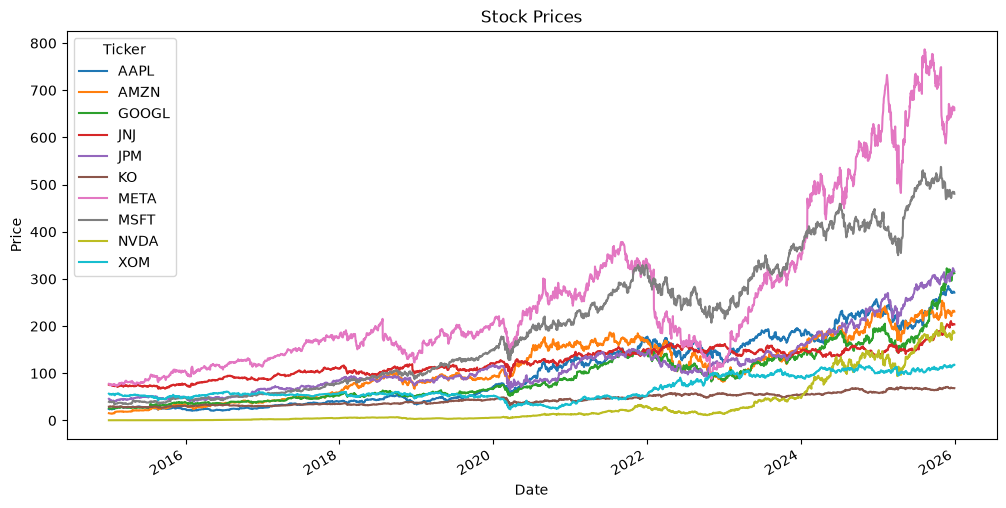

In [47]:
prices.plot(figsize=(12, 6))
plt.title("Stock Prices")
plt.ylabel("Price")
plt.show()

In [48]:
weekly_prices = prices.resample("W-FRI").last()
weekly_prices.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,XOM
Date,,,,,,,,,,
2015-01-02,24.171755,15.4260,26.227924,75.737358,45.838100,29.215921,77.705742,39.607182,0.481884,56.777905
2015-01-09,24.764273,14.8465,24.800009,76.041740,43.527496,29.832968,77.002472,39.971394,0.477336,56.331421
2015-01-16,23.433315,14.5370,25.282421,75.389549,41.026161,29.486320,74.466789,39.166740,0.477814,55.732006
2015-01-23,24.978737,15.6195,26.842077,74.056259,41.576317,30.027100,77.091644,39.962940,0.495768,55.591320
2015-01-30,25.902887,17.7265,26.624153,72.563538,39.889191,28.543417,75.189857,34.220074,0.459621,53.468971


In [49]:
weekly_returns = weekly_prices.pct_change()
weekly_returns = weekly_returns.dropna()
weekly_returns.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,XOM
Date,,,,,,,,,,
2015-01-09,0.024513,-0.037566,-0.054443,0.004019,-0.050408,0.021120,-0.009050,0.009196,-0.009438,-0.007864
2015-01-16,-0.053745,-0.020847,0.019452,-0.008577,-0.057466,-0.011620,-0.032930,-0.020131,0.001003,-0.010641
2015-01-23,0.065950,0.074465,0.061689,-0.017685,0.013410,0.018340,0.035249,0.020328,0.037575,-0.002524
2015-01-30,0.036997,0.134895,-0.008119,-0.020157,-0.040579,-0.049411,-0.024669,-0.143705,-0.072912,-0.038178
2015-02-06,0.019114,0.055708,-0.006827,0.009587,0.064546,0.006801,-0.018970,0.049752,0.062500,0.054549


In [50]:
print(weekly_returns.shape)
print(weekly_returns.describe())

(574, 10)
Ticker        AAPL        AMZN       GOOGL         JNJ         JPM  \
count   574.000000  574.000000  574.000000  574.000000  574.000000   
mean      0.004950    0.005603    0.005071    0.002002    0.004041   
std       0.038172    0.042036    0.038947    0.023539    0.036654   
min      -0.175307   -0.144583   -0.120286   -0.107231   -0.196420   
25%      -0.016868   -0.017605   -0.016887   -0.012205   -0.014772   
50%       0.005342    0.004609    0.005234    0.002241    0.005479   
75%       0.026640    0.029338    0.025930    0.016735    0.024922   
max       0.147330    0.185163    0.258060    0.089396    0.222605   

Ticker          KO        META        MSFT        NVDA         XOM  
count   574.000000  574.000000  574.000000  574.000000  574.000000  
mean      0.001815    0.004899    0.004892    0.012380    0.001983  
std       0.025318    0.048363    0.032785    0.063096    0.037565  
min      -0.209820   -0.236982   -0.143705   -0.200515   -0.200671  
25%      -0.01

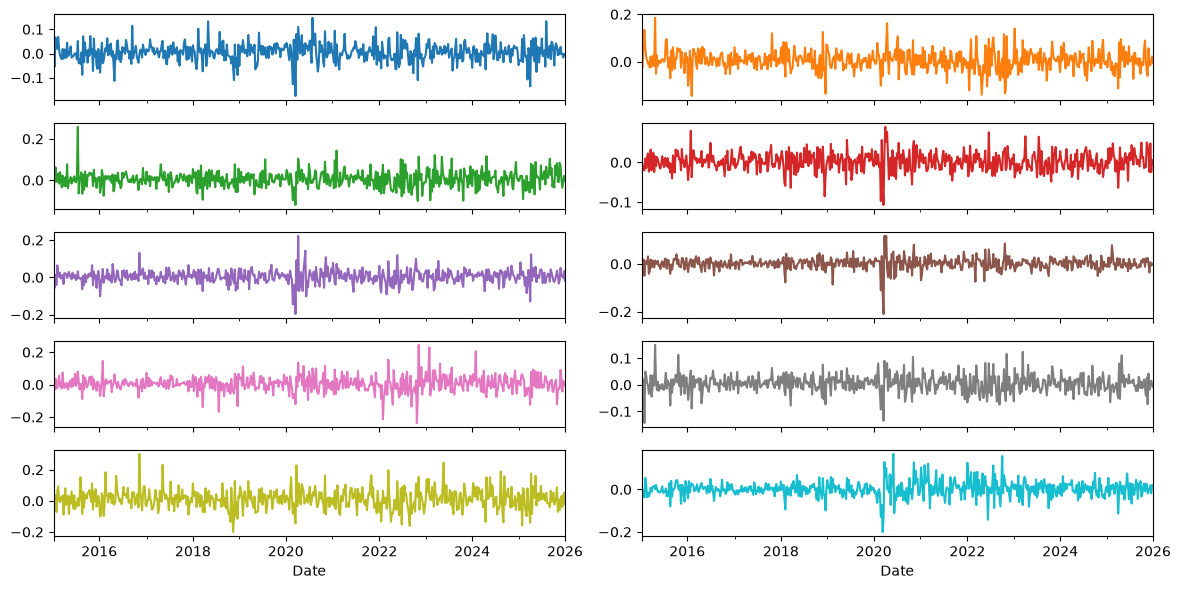

In [51]:
weekly_returns.plot(
    figsize=(12, 6),
    subplots=True,
    layout=(5, 2),
    legend=False
)

plt.tight_layout()
plt.show()

In [52]:
correlation = weekly_returns.corr()
print(correlation.round(2))

Ticker  AAPL  AMZN  GOOGL   JNJ   JPM    KO  META  MSFT  NVDA   XOM
Ticker                                                             
AAPL    1.00  0.48   0.54  0.31  0.36  0.37  0.41  0.57  0.48  0.18
AMZN    0.48  1.00   0.58  0.15  0.31  0.14  0.50  0.61  0.52  0.11
GOOGL   0.54  0.58   1.00  0.24  0.36  0.31  0.51  0.62  0.45  0.21
JNJ     0.31  0.15   0.24  1.00  0.33  0.51  0.13  0.31  0.14  0.29
JPM     0.36  0.31   0.36  0.33  1.00  0.43  0.31  0.38  0.36  0.51
KO      0.37  0.14   0.31  0.51  0.43  1.00  0.21  0.38  0.18  0.36
META    0.41  0.50   0.51  0.13  0.31  0.21  1.00  0.55  0.42  0.12
MSFT    0.57  0.61   0.62  0.31  0.38  0.38  0.55  1.00  0.60  0.19
NVDA    0.48  0.52   0.45  0.14  0.36  0.18  0.42  0.60  1.00  0.16
XOM     0.18  0.11   0.21  0.29  0.51  0.36  0.12  0.19  0.16  1.00


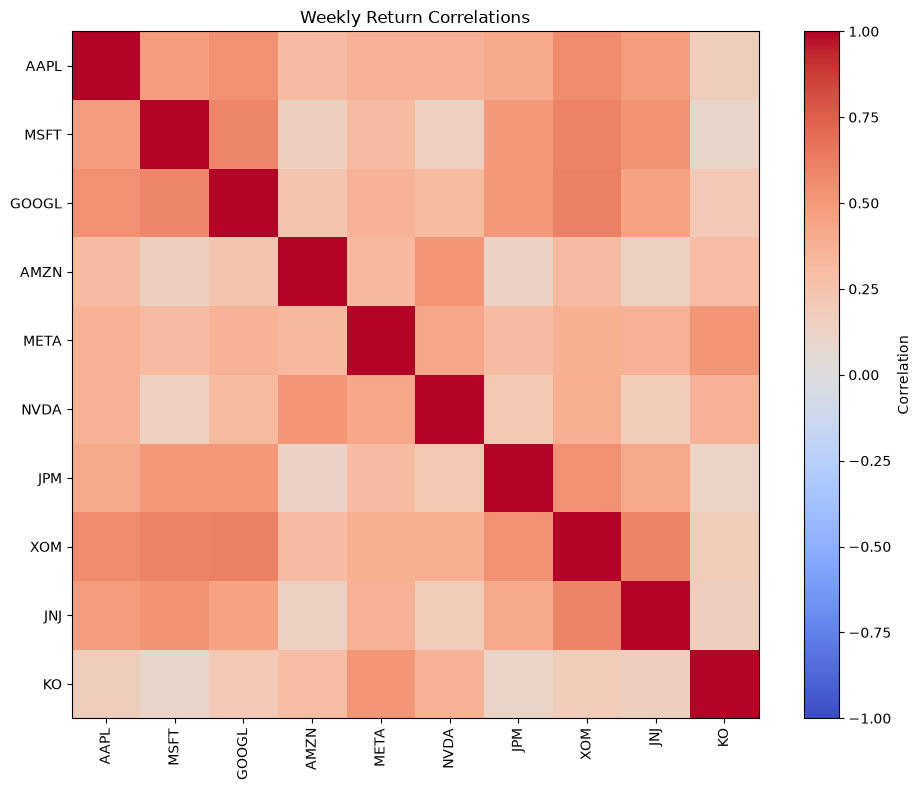

In [53]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(
    range(len(TICKERS)),
    TICKERS,
    rotation=90
)

plt.yticks(
    range(len(TICKERS)),
    TICKERS
)

plt.colorbar(label="Correlation")

plt.title("Weekly Return Correlations")
plt.tight_layout()
plt.show()

In [54]:
covariance = weekly_returns.cov()

print(covariance.round(5))

Ticker     AAPL     AMZN    GOOGL      JNJ      JPM       KO     META  \
Ticker                                                                  
AAPL    0.00146  0.00077  0.00080  0.00028  0.00051  0.00036  0.00076   
AMZN    0.00077  0.00177  0.00095  0.00015  0.00048  0.00015  0.00102   
GOOGL   0.00080  0.00095  0.00152  0.00022  0.00052  0.00031  0.00096   
JNJ     0.00028  0.00015  0.00022  0.00055  0.00028  0.00031  0.00014   
JPM     0.00051  0.00048  0.00052  0.00028  0.00134  0.00040  0.00055   
KO      0.00036  0.00015  0.00031  0.00031  0.00040  0.00064  0.00026   
META    0.00076  0.00102  0.00096  0.00014  0.00055  0.00026  0.00234   
MSFT    0.00071  0.00084  0.00079  0.00024  0.00046  0.00032  0.00086   
NVDA    0.00116  0.00139  0.00110  0.00021  0.00084  0.00029  0.00127   
XOM     0.00026  0.00017  0.00031  0.00026  0.00071  0.00034  0.00021   

Ticker     MSFT     NVDA      XOM  
Ticker                             
AAPL    0.00071  0.00116  0.00026  
AMZN    0.00084

In [55]:
print(weekly_returns.shape)
print(weekly_returns.head())
print(weekly_returns.describe())

(574, 10)
Ticker          AAPL      AMZN     GOOGL       JNJ       JPM        KO  \
Date                                                                     
2015-01-09  0.024513 -0.037566 -0.054443  0.004019 -0.050408  0.021120   
2015-01-16 -0.053745 -0.020847  0.019452 -0.008577 -0.057466 -0.011620   
2015-01-23  0.065950  0.074465  0.061689 -0.017685  0.013410  0.018340   
2015-01-30  0.036997  0.134895 -0.008119 -0.020157 -0.040579 -0.049411   
2015-02-06  0.019114  0.055708 -0.006827  0.009587  0.064546  0.006801   

Ticker          META      MSFT      NVDA       XOM  
Date                                                
2015-01-09 -0.009050  0.009196 -0.009438 -0.007864  
2015-01-16 -0.032930 -0.020131  0.001003 -0.010641  
2015-01-23  0.035249  0.020328  0.037575 -0.002524  
2015-01-30 -0.024669 -0.143705 -0.072912 -0.038178  
2015-02-06 -0.018970  0.049752  0.062500  0.054549  
Ticker        AAPL        AMZN       GOOGL         JNJ         JPM  \
count   574.000000  574.000000

In [56]:
weekly_returns.to_csv("../data/weekly_returns.csv")
weekly_prices.to_csv("../data/weekly_prices.csv")

In [57]:
# ============================================
# STEP 1: Create supervised learning dataset
# ============================================

import numpy as np
import pandas as pd

LOOKBACK = 12  # Use previous 12 weeks to predict the next week

X = []
y = []
dates = []

for i in range(LOOKBACK, len(weekly_returns)):
    
    # Previous 12 weeks of returns
    X.append(
        weekly_returns.iloc[i-LOOKBACK:i].values
    )
    
    # Next week's returns
    y.append(
        weekly_returns.iloc[i].values
    )
    
    # Date of the target week
    dates.append(
        weekly_returns.index[i]
    )

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of samples:", len(X))

X shape: (562, 12, 10)
y shape: (562, 10)
Number of samples: 562


In [58]:
# ============================================
# STEP 1.2: Chronological train/validation/test split
# ============================================

n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

dates_train = dates[:train_end]
dates_val = dates[train_end:val_end]
dates_test = dates[val_end:]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nDate ranges:")
print("Train:", dates_train[0], "to", dates_train[-1])
print("Validation:", dates_val[0], "to", dates_val[-1])
print("Test:", dates_test[0], "to", dates_test[-1])

Training: (393, 12, 10) (393, 10)
Validation: (84, 12, 10) (84, 10)
Test: (85, 12, 10) (85, 10)

Date ranges:
Train: 2015-04-03 00:00:00 to 2022-10-07 00:00:00
Validation: 2022-10-14 00:00:00 to 2024-05-17 00:00:00
Test: 2024-05-24 00:00:00 to 2026-01-02 00:00:00


In [59]:
# Check for NaN values

print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())
print("NaNs in X_val:", np.isnan(X_val).sum())
print("NaNs in y_val:", np.isnan(y_val).sum())
print("NaNs in X_test:", np.isnan(X_test).sum())
print("NaNs in y_test:", np.isnan(y_test).sum())

NaNs in X_train: 0
NaNs in y_train: 0
NaNs in X_val: 0
NaNs in y_val: 0
NaNs in X_test: 0
NaNs in y_test: 0


In [60]:
# ============================================
# STEP 2: Equal-Weight Portfolio Benchmark
# ============================================

N_ASSETS = y_test.shape[1]

# Equal weight for every stock
equal_weights = np.ones(N_ASSETS) / N_ASSETS

print("Number of assets:", N_ASSETS)
print("Weights:", equal_weights)
print("Sum of weights:", equal_weights.sum())

Number of assets: 10
Weights: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Sum of weights: 1.0


In [61]:
# ============================================
# Calculate equal-weight portfolio performance
# ============================================

# Portfolio return each test week
portfolio_returns_equal = y_test @ equal_weights

# Performance metrics
cumulative_return = np.prod(1 + portfolio_returns_equal) - 1

annualized_return = (
    np.prod(1 + portfolio_returns_equal)
    ** (52 / len(portfolio_returns_equal))
    - 1
)

annualized_volatility = (
    np.std(portfolio_returns_equal, ddof=1) * np.sqrt(52)
)

sharpe_ratio = (
    annualized_return / annualized_volatility
)

max_drawdown = (
    np.min(
        np.cumprod(1 + portfolio_returns_equal)
        / np.maximum.accumulate(np.cumprod(1 + portfolio_returns_equal))
        - 1
    )
)

print("Equal-Weight Portfolio — Test Set")
print("-----------------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio:           {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

Equal-Weight Portfolio — Test Set
-----------------------------------
Cumulative Return:     47.06%
Annualized Return:     26.61%
Annualized Volatility: 16.12%
Sharpe Ratio:           1.651
Maximum Drawdown:      -17.51%


In [62]:
# ============================================
# STEP 3: Markowitz Portfolio Optimization
# ============================================

import numpy as np

# Estimate expected returns and covariance
# using TRAINING data only
train_returns = y_train

expected_returns = np.mean(train_returns, axis=0)
cov_matrix = np.cov(train_returns, rowvar=False)

print("Expected returns shape:", expected_returns.shape)
print("Covariance matrix shape:", cov_matrix.shape)

Expected returns shape: (10,)
Covariance matrix shape: (10, 10)


In [63]:
# ============================================
# Solve Markowitz optimization
# ============================================

import cvxpy as cp

weights = cp.Variable(N_ASSETS)

risk_aversion = 1.0

objective = cp.Maximize(
    expected_returns @ weights
    - risk_aversion * cp.quad_form(weights, cov_matrix)
)

constraints = [
    cp.sum(weights) == 1,
    weights >= 0
]

problem = cp.Problem(objective, constraints)
problem.solve()

markowitz_weights = weights.value

print("Markowitz weights:")
for ticker, weight in zip(weekly_returns.columns, markowitz_weights):
    print(f"{ticker}: {weight:.4f}")

print("\nSum of weights:", markowitz_weights.sum())

Markowitz weights:
AAPL: 0.0000
AMZN: 0.0000
GOOGL: 0.0000
JNJ: 0.0000
JPM: 0.0000
KO: 0.0000
META: 0.0000
MSFT: 0.1359
NVDA: 0.8641
XOM: 0.0000

Sum of weights: 1.0


In [64]:
# ============================================
# Markowitz Test Performance
# ============================================

portfolio_returns_markowitz = y_test @ markowitz_weights

cumulative_return = np.prod(1 + portfolio_returns_markowitz) - 1

annualized_return = (
    np.prod(1 + portfolio_returns_markowitz)
    ** (52 / len(portfolio_returns_markowitz))
    - 1
)

annualized_volatility = (
    np.std(portfolio_returns_markowitz, ddof=1) * np.sqrt(52)
)

sharpe_ratio = annualized_return / annualized_volatility

wealth = np.cumprod(1 + portfolio_returns_markowitz)
max_drawdown = np.min(
    wealth / np.maximum.accumulate(wealth) - 1
)

print("Markowitz Portfolio — Test Set")
print("--------------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio:           {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

Markowitz Portfolio — Test Set
--------------------------------
Cumulative Return:     89.83%
Annualized Return:     48.01%
Annualized Volatility: 44.13%
Sharpe Ratio:           1.088
Maximum Drawdown:      -33.24%


In [65]:
# ============================================
# STEP 4: Prepare data for PyTorch
# ============================================

import torch
from torch import nn

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

X_train: torch.Size([393, 12, 10])
y_train: torch.Size([393, 10])


In [66]:
# ============================================
# STEP 4.1: Simple Neural Network
# ============================================

class ReturnPredictor(nn.Module):
    def __init__(self, n_assets):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(12 * n_assets, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, n_assets)
        )

    def forward(self, x):
        return self.network(x)


model = ReturnPredictor(N_ASSETS)

print(model)

ReturnPredictor(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [67]:
# ============================================
# STEP 4.2: Training setup
# ============================================

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model ready.")

Model ready.


In [68]:
# ============================================
# STEP 5: Train Neural Network
# ============================================

EPOCHS = 100

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # Training
    model.train()

    optimizer.zero_grad()

    train_predictions = model(X_train_tensor)
    train_loss = loss_function(train_predictions, y_train_tensor)

    train_loss.backward()
    optimizer.step()

    # Validation
    model.eval()

    with torch.no_grad():
        val_predictions = model(X_val_tensor)
        val_loss = loss_function(val_predictions, y_val_tensor)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Loss: {train_loss.item():.6f} | "
            f"Validation Loss: {val_loss.item():.6f}"
        )

Epoch  10 | Train Loss: 0.010208 | Validation Loss: 0.010352
Epoch  20 | Train Loss: 0.006172 | Validation Loss: 0.006365
Epoch  30 | Train Loss: 0.003339 | Validation Loss: 0.003635
Epoch  40 | Train Loss: 0.002052 | Validation Loss: 0.002511
Epoch  50 | Train Loss: 0.001596 | Validation Loss: 0.002101
Epoch  60 | Train Loss: 0.001503 | Validation Loss: 0.001968
Epoch  70 | Train Loss: 0.001443 | Validation Loss: 0.001907
Epoch  80 | Train Loss: 0.001384 | Validation Loss: 0.001935
Epoch  90 | Train Loss: 0.001328 | Validation Loss: 0.001946
Epoch 100 | Train Loss: 0.001266 | Validation Loss: 0.001957


In [69]:
# ============================================
# STEP 5.1: Evaluate on Test Set
# ============================================

model.eval()

with torch.no_grad():
    test_predictions = model(X_test_tensor)

test_loss = loss_function(test_predictions, y_test_tensor)

print(f"Test MSE: {test_loss.item():.6f}")

Test MSE: 0.001606


In [70]:
# ============================================
# STEP 6: ML Prediction → Markowitz Portfolio
# ============================================

# Use validation data to generate predicted returns
model.eval()

with torch.no_grad():
    val_predictions = model(X_val_tensor).numpy()

print("Predicted returns shape:", val_predictions.shape)

Predicted returns shape: (84, 10)


In [71]:
# ============================================
# Optimize portfolio for each validation week
# ============================================

import cvxpy as cp

ml_portfolio_weights = []

for predicted_return in val_predictions:

    w = cp.Variable(N_ASSETS)

    objective = cp.Maximize(
        predicted_return @ w
        - risk_aversion * cp.quad_form(w, cov_matrix)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    ml_portfolio_weights.append(w.value)

ml_portfolio_weights = np.array(ml_portfolio_weights)

print("Portfolio weights shape:", ml_portfolio_weights.shape)
print("First week's weights:")
print(ml_portfolio_weights[0])
print("First week's weight sum:", ml_portfolio_weights[0].sum())

Portfolio weights shape: (84, 10)
First week's weights:
[5.02728423e-24 1.14617421e-22 1.15402022e-22 1.18586715e-23
 1.03156376e-23 1.08779307e-23 2.27820302e-22 1.00000000e+00
 4.07522000e-26 6.91260438e-23]
First week's weight sum: 1.0


In [72]:
# ============================================
# Evaluate ML → Optimization pipeline
# ============================================

ml_validation_returns = np.sum(
    ml_portfolio_weights * y_val,
    axis=1
)

cumulative_return = np.prod(1 + ml_validation_returns) - 1

annualized_return = (
    np.prod(1 + ml_validation_returns)
    ** (52 / len(ml_validation_returns))
    - 1
)

annualized_volatility = (
    np.std(ml_validation_returns, ddof=1) * np.sqrt(52)
)

sharpe_ratio = annualized_return / annualized_volatility

wealth = np.cumprod(1 + ml_validation_returns)

max_drawdown = np.min(
    wealth / np.maximum.accumulate(wealth) - 1
)

print("ML → Markowitz — Validation Set")
print("--------------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio:           {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

ML → Markowitz — Validation Set
--------------------------------
Cumulative Return:     114.93%
Annualized Return:     60.59%
Annualized Volatility: 41.50%
Sharpe Ratio:           1.460
Maximum Drawdown:      -22.14%


In [73]:
# ============================================
# STEP 7: ML → Markowitz — Test Set
# ============================================

# Generate test predictions
model.eval()

with torch.no_grad():
    test_predictions = model(X_test_tensor).numpy()

print("Test predictions shape:", test_predictions.shape)

Test predictions shape: (85, 10)


In [74]:
# Optimize portfolio for each test week

ml_test_weights = []

for predicted_return in test_predictions:

    w = cp.Variable(N_ASSETS)

    objective = cp.Maximize(
        predicted_return @ w
        - risk_aversion * cp.quad_form(w, cov_matrix)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    ml_test_weights.append(w.value)

ml_test_weights = np.array(ml_test_weights)

print("Test portfolio weights shape:", ml_test_weights.shape)

Test portfolio weights shape: (85, 10)


In [75]:
# Evaluate on actual test returns

ml_test_returns = np.sum(
    ml_test_weights * y_test,
    axis=1
)

cumulative_return = np.prod(1 + ml_test_returns) - 1

annualized_return = (
    np.prod(1 + ml_test_returns)
    ** (52 / len(ml_test_returns))
    - 1
)

annualized_volatility = (
    np.std(ml_test_returns, ddof=1) * np.sqrt(52)
)

sharpe_ratio = annualized_return / annualized_volatility

wealth = np.cumprod(1 + ml_test_returns)

max_drawdown = np.min(
    wealth / np.maximum.accumulate(wealth) - 1
)

print("ML → Markowitz — Test Set")
print("--------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio:           {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

ML → Markowitz — Test Set
--------------------------
Cumulative Return:     249.90%
Annualized Return:     115.16%
Annualized Volatility: 33.72%
Sharpe Ratio:           3.415
Maximum Drawdown:      -14.60%


In [76]:
# ============================================
# STEP 8: Prediction Accuracy Comparison
# ============================================

from sklearn.metrics import mean_squared_error, mean_absolute_error

test_mse = mean_squared_error(
    y_test.flatten(),
    test_predictions.flatten()
)

test_mae = mean_absolute_error(
    y_test.flatten(),
    test_predictions.flatten()
)

print("Prediction Performance — Test Set")
print("----------------------------------")
print(f"MSE: {test_mse:.6f}")
print(f"MAE: {test_mae:.6f}")

Prediction Performance — Test Set
----------------------------------
MSE: 0.001606
MAE: 0.029461


In [ ]:
# Baseline prediction: historical mean return from training data

mean_predictions = np.tile(
    expected_returns,
    (len(y_test), 1)
)

mean_mse = mean_squared_error(
    y_test.flatten(),
    mean_predictions.flatten()
)

mean_mae = mean_absolute_error(
    y_test.flatten(),
    mean_predictions.flatten()
)

print("Historical Mean Predictor")
print("-------------------------")
print(f"MSE: {mean_mse:.6f}")
print(f"MAE: {mean_mae:.6f}")

Historical Mean Predictor
-------------------------
MSE: 0.001557
MAE: 0.028674


In [80]:
# ============================================
# STEP 9: Historical Mean → Markowitz
# ============================================

mean_test_weights = []

for predicted_return in mean_predictions:
    w = cp.Variable(N_ASSETS)

    objective = cp.Maximize(
        predicted_return @ w
        - risk_aversion * cp.quad_form(w, cov_matrix)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    if w.value is None:
        raise ValueError("Portfolio optimization failed.")

    mean_test_weights.append(w.value)

mean_test_weights = np.array(mean_test_weights)

mean_test_returns = np.sum(
    mean_test_weights * y_test,
    axis=1
)

cumulative_return = np.prod(1 + mean_test_returns) - 1
annualized_return = (
    np.prod(1 + mean_test_returns) ** (52 / len(mean_test_returns)) - 1
)
annualized_volatility = (
    np.std(mean_test_returns, ddof=1) * np.sqrt(52)
)
sharpe_ratio = annualized_return / annualized_volatility

wealth = np.cumprod(1 + mean_test_returns)
max_drawdown = np.min(
    wealth / np.maximum.accumulate(wealth) - 1
)

print("Historical Mean → Markowitz — Test Set")
print("---------------------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio:           {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

Historical Mean → Markowitz — Test Set
---------------------------------------
Cumulative Return:     89.83%
Annualized Return:     48.01%
Annualized Volatility: 44.13%
Sharpe Ratio:           1.088
Maximum Drawdown:      -33.24%


In [81]:
# ============================================
# STEP 10: Compare All Portfolio Strategies
# ============================================

results = pd.DataFrame([
    {
        "Strategy": "Equal Weight",
        "Annualized Return (%)": 26.61,
        "Annualized Volatility (%)": 16.12,
        "Sharpe Ratio": 1.651,
        "Max Drawdown (%)": -17.51
    },
    {
        "Strategy": "Markowitz",
        "Annualized Return (%)": 48.01,
        "Annualized Volatility (%)": 44.13,
        "Sharpe Ratio": 1.088,
        "Max Drawdown (%)": -33.24
    },
    {
        "Strategy": "Neural Network → Markowitz",
        "Annualized Return (%)": 43.77,
        "Annualized Volatility (%)": 34.32,
        "Sharpe Ratio": 1.275,
        "Max Drawdown (%)": -25.77
    },
    {
        "Strategy": "Historical Mean → Markowitz",
        "Annualized Return (%)": 48.01,
        "Annualized Volatility (%)": 44.13,
        "Sharpe Ratio": 1.088,
        "Max Drawdown (%)": -33.24
    }
])

results = results.round(3)
display(results)

,Strategy,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Max Drawdown (%)
0,Equal Weight,26.61,16.12,1.651,-17.51
1,Markowitz,48.01,44.13,1.088,-33.24
2,Neural Network → Markowitz,43.77,34.32,1.275,-25.77
3,Historical Mean → Markowitz,48.01,44.13,1.088,-33.24
